# 02 - Analise temporal, receita e categorias

Aqui eu olho para volume de pedidos, receita, frete, estados e categorias. A base usada e o `olist_colab.sqlite` criado no notebook 01 ou baixado da Release.

In [9]:
from pathlib import Path
import sqlite3
import urllib.request
import zipfile

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

PROJECT_DIR = Path.cwd()
DB_ZIP_URL = "https://github.com/Urpia-S/Olist_E-commerce_Analytic-SQL-Python/releases/download/data-v1/olist_colab.sqlite.zip"
OUTPUT_DIR = PROJECT_DIR / "outputs_colab"
DB_PATH = PROJECT_DIR / "olist_colab.sqlite"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def baixar_banco_da_release():
    zip_path = PROJECT_DIR / "olist_colab.sqlite.zip"
    urllib.request.urlretrieve(DB_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(PROJECT_DIR)

    print("Banco extraido em:", DB_PATH)


if not DB_PATH.exists():
    baixar_banco_da_release()

conn = sqlite3.connect(DB_PATH)


def consulta(sql):
    return pd.read_sql_query(sql, conn)


def salvar_consulta(sql, arquivo):
    df = consulta(sql)
    destino = OUTPUT_DIR / arquivo
    df.to_csv(destino, index=False)
    print(f"Arquivo salvo: {destino}")
    return df


def grafico_barras(df, x, y, titulo, rotacao=0, top=None):
    dados = df.head(top) if top else df
    ax = dados.plot(kind="bar", x=x, y=y, legend=False, figsize=(10, 4))
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel(y)
    plt.xticks(rotation=rotacao, ha="right" if rotacao else "center")
    plt.tight_layout()
    plt.show()


consulta("""
-- Objetos disponiveis no banco preparado.
SELECT
    type AS tipo,
    name AS objeto
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name
LIMIT 20;
""")

,tipo,objeto
0,table,core_customers
1,table,core_geolocation_zip_city
2,table,core_order_items
3,table,core_order_payments
4,table,core_order_reviews
5,table,core_orders
6,table,core_product_category_translation
7,table,core_products
8,table,core_sellers
9,table,stg_customers


## 1. Pedidos ao longo do tempo

Primeiro verifico a evolucao dos pedidos por mes, dia da semana e hora.

In [10]:
pedidos_por_mes = salvar_consulta("""
-- Agrupo pedidos por mes para enxergar evolucao temporal.
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS mes_pedido,
    COUNT(*) AS pedidos,
    SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) AS pedidos_entregues,
    COUNT(DISTINCT customer_id) AS clientes
FROM core_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY strftime('%Y-%m', order_purchase_timestamp)
ORDER BY mes_pedido;
""", "pedidos_por_mes.csv")

pedidos_por_mes.head()

Arquivo salvo: /content/outputs_colab/pedidos_por_mes.csv


,mes_pedido,pedidos,pedidos_entregues,clientes
0,2016-09,4,1,4
1,2016-10,324,265,324
2,2016-12,1,1,1
3,2017-01,800,750,800
4,2017-02,1780,1653,1780


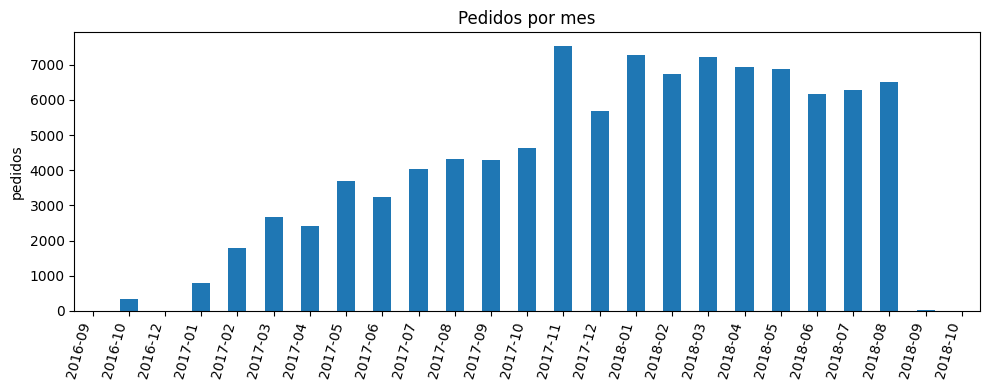

In [11]:
grafico_barras(pedidos_por_mes, "mes_pedido", "pedidos", "Pedidos por mes", rotacao=75)

In [12]:
pedidos_por_dia_semana = salvar_consulta("""
-- Distribuicao dos pedidos por dia da semana.
SELECT
    CAST(strftime('%w', order_purchase_timestamp) AS INTEGER) AS numero_dia_sqlite,
    CASE CAST(strftime('%w', order_purchase_timestamp) AS INTEGER)
        WHEN 0 THEN 'domingo'
        WHEN 1 THEN 'segunda'
        WHEN 2 THEN 'terca'
        WHEN 3 THEN 'quarta'
        WHEN 4 THEN 'quinta'
        WHEN 5 THEN 'sexta'
        WHEN 6 THEN 'sabado'
    END AS dia_semana,
    COUNT(*) AS pedidos
FROM core_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY numero_dia_sqlite, dia_semana
ORDER BY numero_dia_sqlite;
""", "pedidos_por_dia_semana.csv")

pedidos_por_hora = salvar_consulta("""
-- Distribuicao dos pedidos por hora do dia.
SELECT
    CAST(strftime('%H', order_purchase_timestamp) AS INTEGER) AS hora_do_dia,
    COUNT(*) AS pedidos
FROM core_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY CAST(strftime('%H', order_purchase_timestamp) AS INTEGER)
ORDER BY hora_do_dia;
""", "pedidos_por_hora.csv")

display(pedidos_por_dia_semana)
display(pedidos_por_hora.head())

Arquivo salvo: /content/outputs_colab/pedidos_por_dia_semana.csv
Arquivo salvo: /content/outputs_colab/pedidos_por_hora.csv


,numero_dia_sqlite,dia_semana,pedidos
0,0,domingo,11960
1,1,segunda,16196
2,2,terca,15963
3,3,quarta,15552
4,4,quinta,14761
5,5,sexta,14122
6,6,sabado,10887


,hora_do_dia,pedidos
0,0,2394
1,1,1170
2,2,510
3,3,272
4,4,206


## 2. Receita, frete e categorias

Nesta parte comparo receita mensal, categorias e estados dos clientes.

In [13]:
metricas_receita_mensal = salvar_consulta("""
-- Receita mensal com ticket medio e frete medio por item.
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS mes_pedido,
    COUNT(DISTINCT o.order_id) AS pedidos,
    COUNT(DISTINCT c.customer_unique_id) AS clientes_unicos,
    ROUND(SUM(oi.price), 2) AS receita_produtos,
    ROUND(SUM(oi.freight_value), 2) AS receita_frete,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS receita_total_com_frete,
    ROUND(SUM(oi.price) / NULLIF(COUNT(DISTINCT o.order_id), 0), 2) AS ticket_medio_produtos,
    ROUND(AVG(oi.freight_value), 2) AS frete_medio_item
FROM core_orders o
JOIN core_customers c ON c.customer_id = o.customer_id
JOIN core_order_items oi ON oi.order_id = o.order_id
WHERE o.order_purchase_timestamp IS NOT NULL
GROUP BY strftime('%Y-%m', o.order_purchase_timestamp)
ORDER BY mes_pedido;
""", "metricas_receita_mensal.csv")

receita_por_categoria = salvar_consulta("""
-- Receita e frete por categoria traduzida.
SELECT
    categoria_ingles,
    COUNT(DISTINCT order_id) AS pedidos,
    COUNT(*) AS itens_vendidos,
    ROUND(SUM(price), 2) AS receita_produtos,
    ROUND(SUM(freight_value), 2) AS receita_frete,
    ROUND(SUM(price) / NULLIF(COUNT(DISTINCT order_id), 0), 2) AS ticket_medio_pedido_categoria,
    ROUND(AVG(freight_value), 2) AS frete_medio_item
FROM vw_order_items_enriched
GROUP BY categoria_ingles
ORDER BY receita_produtos DESC;
""", "receita_por_categoria.csv")

receita_por_categoria.head(10)

Arquivo salvo: /content/outputs_colab/metricas_receita_mensal.csv
Arquivo salvo: /content/outputs_colab/receita_por_categoria.csv


,categoria_ingles,pedidos,itens_vendidos,receita_produtos,receita_frete,ticket_medio_pedido_categoria,frete_medio_item
0,health_beauty,8836,9670,1258681.34,182566.73,142.45,18.88
1,watches_gifts,5624,5991,1205005.68,100535.93,214.26,16.78
2,bed_bath_table,9417,11115,1036988.68,204693.04,110.12,18.42
3,sports_leisure,7720,8641,988048.97,168607.51,127.99,19.51
4,computers_accessories,6689,7827,911954.32,147318.08,136.34,18.82
5,furniture_decor,6449,8334,729762.49,172749.30,113.16,20.73
6,cool_stuff,3632,3796,635290.85,84039.10,174.91,22.14
7,housewares,5884,6964,632248.66,146149.11,107.45,20.99
8,auto,3897,4235,592720.11,92664.21,152.10,21.88
9,garden_tools,3518,4347,485256.46,98962.75,137.94,22.77


In [14]:

categorias_metricas = salvar_consulta("""
-- Metricas consolidadas por categoria.
SELECT
    categoria_ingles,
    COUNT(DISTINCT order_id) AS pedidos,
    COUNT(*) AS itens_vendidos,
    ROUND(SUM(price), 2) AS receita_produtos,
    ROUND(AVG(price), 2) AS preco_medio_item,
    ROUND(AVG(freight_value), 2) AS frete_medio_item,
    ROUND(SUM(price) / NULLIF(COUNT(DISTINCT order_id), 0), 2) AS ticket_medio_por_pedido
FROM vw_order_items_enriched
GROUP BY categoria_ingles
ORDER BY receita_produtos DESC;
""", "categorias_metricas.csv")

categorias_metricas.head(10)


Arquivo salvo: /content/outputs_colab/categorias_metricas.csv


,categoria_ingles,pedidos,itens_vendidos,receita_produtos,preco_medio_item,frete_medio_item,ticket_medio_por_pedido
0,health_beauty,8836,9670,1258681.34,130.16,18.88,142.45
1,watches_gifts,5624,5991,1205005.68,201.14,16.78,214.26
2,bed_bath_table,9417,11115,1036988.68,93.30,18.42,110.12
3,sports_leisure,7720,8641,988048.97,114.34,19.51,127.99
4,computers_accessories,6689,7827,911954.32,116.51,18.82,136.34
5,furniture_decor,6449,8334,729762.49,87.56,20.73,113.16
6,cool_stuff,3632,3796,635290.85,167.36,22.14,174.91
7,housewares,5884,6964,632248.66,90.79,20.99,107.45
8,auto,3897,4235,592720.11,139.96,21.88,152.10
9,garden_tools,3518,4347,485256.46,111.63,22.77,137.94


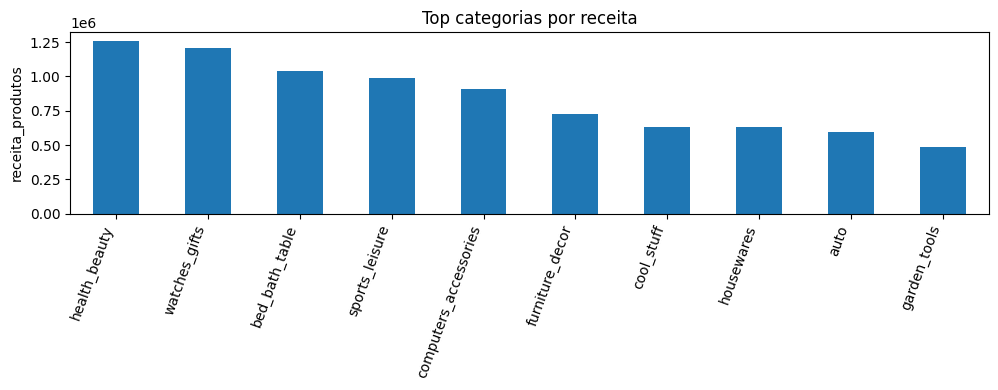

In [15]:
grafico_barras(receita_por_categoria, "categoria_ingles", "receita_produtos", "Top categorias por receita", rotacao=70, top=10)

In [16]:
receita_por_estado = salvar_consulta("""
-- Receita por estado do cliente.
SELECT
    c.customer_state AS estado_cliente,
    COUNT(DISTINCT o.order_id) AS pedidos,
    COUNT(DISTINCT c.customer_unique_id) AS clientes_unicos,
    ROUND(SUM(oi.price), 2) AS receita_produtos,
    ROUND(SUM(oi.freight_value), 2) AS receita_frete,
    ROUND(SUM(oi.price) / NULLIF(COUNT(DISTINCT o.order_id), 0), 2) AS ticket_medio_produtos
FROM core_orders o
JOIN core_customers c ON c.customer_id = o.customer_id
JOIN core_order_items oi ON oi.order_id = o.order_id
GROUP BY c.customer_state
ORDER BY receita_produtos DESC;
""", "receita_por_estado.csv")

receita_por_estado.head()

Arquivo salvo: /content/outputs_colab/receita_por_estado.csv


,estado_cliente,pedidos,clientes_unicos,receita_produtos,receita_frete,ticket_medio_produtos
0,SP,41375,39981,5202955.05,718723.07,125.75
1,RJ,12762,12303,1824092.67,305589.31,142.93
2,MG,11544,11178,1585308.03,270853.46,137.33
3,RS,5432,5249,750304.02,135522.74,138.13
4,PR,4998,4840,683083.76,117851.68,136.67
